# 05 Explainability

**Assignment 2: Explainable Maternal Health Risk Prediction** · KQC7016 Data Analytics

The classifier (notebook 03) predicts risk; here we explain *why*. Three complementary
layers:

1. **SHAP** — game-theoretic feature attributions, globally (which vitals drive the model)
   and locally (why *this* patient was flagged).
2. **Association-rule matching** — which mined `vitals → risk` rules (notebook 04) a given
   patient satisfies.
3. **Structured evidence** — we package prediction + SHAP + matched rules per patient into
   a JSON record (`data/patient_evidence.json`) that the SLM narrative (notebook 06) turns
   into readable clinical text.

We explain the **Random Forest** (best macro-F1 in notebook 03).

In [1]:
import joblib, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path

PLOTS = Path("plots")
FEATURES = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]
CLASS_NAMES = ["low", "mid", "high"]   # encoded 0/1/2

rf = joblib.load("data/models/random_forest.joblib")
test = pd.read_csv("data/test.csv")
X_test = test[FEATURES]
y_test = test["risk_encoded"].astype(int)
proba = rf.predict_proba(X_test)
pred = rf.predict(X_test)
print("Loaded RF + test set:", X_test.shape)

Loaded RF + test set: (91, 6)


## 1. SHAP values

`TreeExplainer` returns an array of shape *(samples, features, classes)*. For any patient,
the SHAP value of a feature for a class is how much that feature pushed the predicted
probability of that class up (+) or down (−) from the base rate.

In [2]:
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_test)          # (n, features, classes)
base_vals = np.array(explainer.expected_value)     # (classes,)
if isinstance(shap_vals, list):                    # robustness across shap versions
    shap_vals = np.stack(shap_vals, axis=-1)
print("shap_vals:", shap_vals.shape, "| base:", base_vals.shape)

shap_vals: (91, 6, 3) | base: (3,)


## 2. Global importance — mean |SHAP| per class

Averaging the absolute SHAP values over all test patients shows which vitals matter most
for each risk class. Blood sugar and blood pressure should dominate, agreeing with the
tree-based importance in notebook 03.

                low     mid    high  overall
BS           0.1331  0.0450  0.1669   0.1150
SystolicBP   0.0788  0.0472  0.0970   0.0743
BodyTemp     0.0776  0.0229  0.0591   0.0532
Age          0.0331  0.0278  0.0250   0.0286
HeartRate    0.0234  0.0218  0.0222   0.0225
DiastolicBP  0.0209  0.0194  0.0261   0.0222


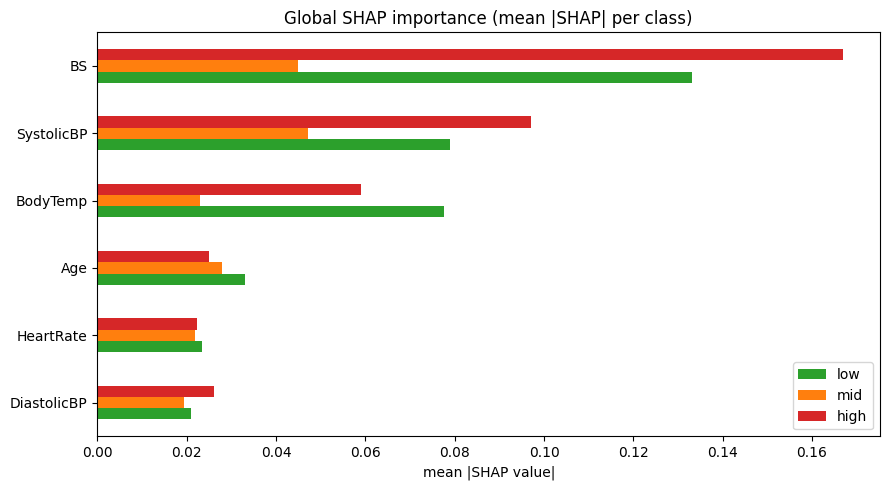

In [3]:
mean_abs = np.abs(shap_vals).mean(axis=0)          # (features, classes)
imp = pd.DataFrame(mean_abs, index=FEATURES, columns=CLASS_NAMES)
imp["overall"] = imp.mean(axis=1)
imp = imp.sort_values("overall", ascending=True)
print(imp.round(4).sort_values("overall", ascending=False))

ax = imp[CLASS_NAMES].plot.barh(figsize=(9, 5),
        color={"low": "#2ca02c", "mid": "#ff7f0e", "high": "#d62728"})
ax.set_title("Global SHAP importance (mean |SHAP| per class)")
ax.set_xlabel("mean |SHAP value|")
plt.tight_layout(); plt.savefig(PLOTS / "18_shap_global_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. SHAP beeswarm — high-risk class

The beeswarm shows, for the **high-risk** class, how each feature's value (colour) relates
to its SHAP impact (x). High blood sugar / blood pressure (red points on the right) push
patients toward high risk.

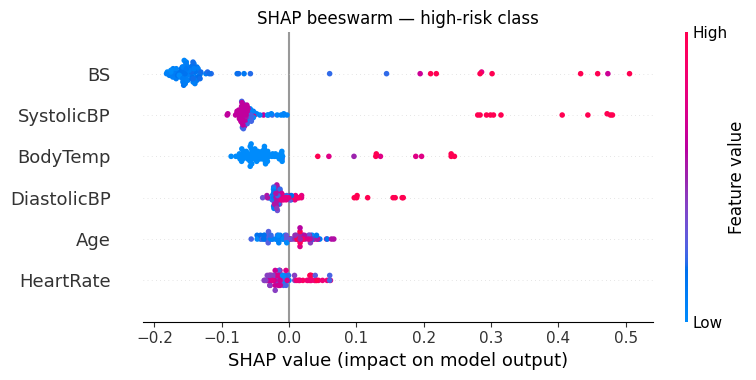

In [4]:
HIGH = 2
plt.figure()
shap.summary_plot(shap_vals[:, :, HIGH], X_test, feature_names=FEATURES, show=False)
plt.title("SHAP beeswarm — high-risk class", fontsize=12)
plt.tight_layout(); plt.savefig(PLOTS / "19_shap_beeswarm_high.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Local explanation — one patient

A waterfall plot for a single correctly-predicted high-risk patient shows exactly which
vitals drove that individual prediction — the patient-level interpretability clinicians
need.

Patient row 6: true=high, pred=high, P(high)=0.97
{'Age': 63.0, 'SystolicBP': 140.0, 'DiastolicBP': 90.0, 'BS': 15.0, 'BodyTemp': 98.0, 'HeartRate': 90.0}


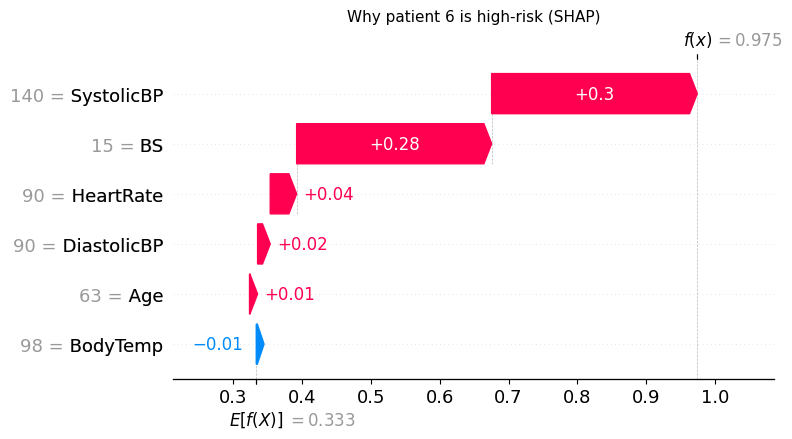

In [5]:
# pick a correctly-predicted high-risk patient with highest confidence
high_idx = [i for i in range(len(y_test)) if y_test[i] == HIGH and pred[i] == HIGH]
i = max(high_idx, key=lambda k: proba[k, HIGH])
print(f"Patient row {i}: true=high, pred=high, P(high)={proba[i, HIGH]:.2f}")
print(X_test.iloc[i].to_dict())

expl = shap.Explanation(
    values=shap_vals[i, :, HIGH], base_values=base_vals[HIGH],
    data=X_test.iloc[i].values, feature_names=FEATURES)
shap.plots.waterfall(expl, show=False)
plt.title(f"Why patient {i} is high-risk (SHAP)", fontsize=11)
plt.tight_layout(); plt.savefig(PLOTS / "20_shap_waterfall_patient.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Association-rule matching

For a patient we discretise their vitals (same clinical bins as notebook 04) and find which
mined rules they satisfy — a complementary, guideline-grounded explanation alongside SHAP.

In [6]:
rules = pd.read_csv("data/association_rules.csv")
rules["ante_set"] = rules["antecedent"].apply(lambda s: frozenset(x.strip() for x in s.split(",")))

def patient_items(row):
    sbp = "SBP_high" if row.SystolicBP >= 140 else ("SBP_elevated" if row.SystolicBP >= 120 else "SBP_normal")
    dbp = "DBP_high" if row.DiastolicBP >= 90 else ("DBP_elevated" if row.DiastolicBP >= 80 else "DBP_normal")
    bs  = "BS_high" if row.BS >= 7.0 else "BS_normal"
    tmp = "Temp_fever" if row.BodyTemp >= 100.4 else "Temp_normal"
    age = "Age_older" if row.Age >= 35 else ("Age_young" if row.Age < 20 else "Age_adult")
    return frozenset([sbp, dbp, bs, tmp, age])

def match_rules(row, risk=None, top=5):
    items = patient_items(row)
    m = rules[rules["ante_set"].apply(lambda a: a <= items)].copy()
    if risk is not None:
        m = m[m["risk"] == risk]
    return m.sort_values("lift", ascending=False).head(top)

pr = "Risk_" + CLASS_NAMES[pred[i]]
print(f"Patient {i} items: {sorted(patient_items(X_test.iloc[i]))}")
print(f"Matched rules -> {pr}:")
match_rules(X_test.iloc[i], risk=pr)[["antecedent", "risk", "support", "confidence", "lift"]].round(3)

Patient 6 items: ['Age_older', 'BS_high', 'DBP_high', 'SBP_high', 'Temp_normal']
Matched rules -> Risk_high:


,antecedent,risk,support,confidence,lift
0,"DBP_high, SBP_high",Risk_high,0.082,1.0,4.027
9,"Age_older, BS_high, SBP_high, Temp_normal",Risk_high,0.049,1.0,4.027
1,"DBP_high, SBP_high, Temp_normal",Risk_high,0.075,1.0,4.027
12,"BS_high, SBP_high, Temp_normal",Risk_high,0.078,1.0,4.027
11,"Age_older, DBP_high, SBP_high",Risk_high,0.049,1.0,4.027


## 6. Structured evidence for the SLM (notebook 06)

We bundle everything a narrative needs — prediction, probabilities, top SHAP drivers, and
matched rules — into one JSON record per patient. We export a small set of example patients
(one per risk class where available) for the SLM module to narrate.

In [7]:
def build_evidence(i):
    row = X_test.iloc[i]
    p = int(pred[i]); pr = "Risk_" + CLASS_NAMES[p]
    # top-3 features by |SHAP| for the predicted class, signed
    sv = shap_vals[i, :, p]
    order = np.argsort(np.abs(sv))[::-1][:3]
    top_features = [{
        "feature": FEATURES[k],
        "value": float(row.iloc[k]),
        "shap": round(float(sv[k]), 4),
        "direction": "increases" if sv[k] > 0 else "decreases",
    } for k in order]
    matched = match_rules(row, risk=pr, top=3)
    rule_list = [{
        "antecedent": r["antecedent"], "confidence": round(float(r["confidence"]), 3),
        "lift": round(float(r["lift"]), 2),
    } for _, r in matched.iterrows()]
    return {
        "patient_id": int(i),
        "vitals": {f: float(row[f]) for f in FEATURES},
        "true_risk": CLASS_NAMES[int(y_test[i])],
        "predicted_risk": CLASS_NAMES[p],
        "confidence": round(float(proba[i, p]), 3),
        "class_probabilities": {CLASS_NAMES[k]: round(float(proba[i, k]), 3) for k in range(3)},
        "top_features": top_features,
        "matched_rules": rule_list,
    }

# one well-predicted example per class (fallback: any of that true class)
examples = []
for cls in [2, 1, 0]:
    correct = [k for k in range(len(y_test)) if y_test[k] == cls and pred[k] == cls]
    pool = correct if correct else [k for k in range(len(y_test)) if y_test[k] == cls]
    if pool:
        examples.append(max(pool, key=lambda k: proba[k, pred[k]]))

evidence = [build_evidence(i) for i in examples]
Path("data/patient_evidence.json").write_text(json.dumps(evidence, indent=2))
print(f"Saved {len(evidence)} patient evidence records to data/patient_evidence.json")
print(json.dumps(evidence[0], indent=2))

Saved 3 patient evidence records to data/patient_evidence.json
{
  "patient_id": 6,
  "vitals": {
    "Age": 63.0,
    "SystolicBP": 140.0,
    "DiastolicBP": 90.0,
    "BS": 15.0,
    "BodyTemp": 98.0,
    "HeartRate": 90.0
  },
  "true_risk": "high",
  "predicted_risk": "high",
  "confidence": 0.975,
  "class_probabilities": {
    "low": 0.005,
    "mid": 0.02,
    "high": 0.975
  },
  "top_features": [
    {
      "feature": "SystolicBP",
      "value": 140.0,
      "shap": 0.2991,
      "direction": "increases"
    },
    {
      "feature": "BS",
      "value": 15.0,
      "shap": 0.2836,
      "direction": "increases"
    },
    {
      "feature": "HeartRate",
      "value": 90.0,
      "shap": 0.0384,
      "direction": "increases"
    }
  ],
  "matched_rules": [
    {
      "antecedent": "DBP_high, SBP_high",
      "confidence": 1.0,
      "lift": 4.03
    },
    {
      "antecedent": "Age_older, BS_high, SBP_high, Temp_normal",
      "confidence": 1.0,
      "lift": 4.03
    },

## Summary

- **Global SHAP** confirms blood sugar and blood pressure as the dominant risk drivers,
  matching the tree-based importance and the association rules.
- **Local SHAP** (waterfall) and **rule matching** give patient-specific, complementary
  explanations — one model-based, one guideline-grounded.
- Per-patient **structured evidence** is exported to `data/patient_evidence.json` for the
  SLM narrative module.

Next: **06_slm_narrative**.